In [1]:
import pandas as pd
melborn_data = pd.read_csv('datasets/melb_data.csv')

melborn_data.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [2]:
melborn_data.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [3]:
# Drop rows with missing values. 
melborn_data = melborn_data.dropna(axis = 0)

In [4]:
# Get the targets. 
y = melborn_data.Price

In [5]:
melborn_features = ['Rooms','Bathroom','Landsize','Lattitude','Longtitude']
# Select features 
X = melborn_data[melborn_features]

In [6]:
# Let's check out the data. 
X.describe()

,Rooms,Bathroom,Landsize,Lattitude,Longtitude
count,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000
mean,2.931407,1.576340,471.006940,-37.807904,144.990201
std,0.971079,0.711362,897.449881,0.075850,0.099165
min,1.000000,1.000000,0.000000,-38.164920,144.542370
25%,2.000000,1.000000,152.000000,-37.855438,144.926198
50%,3.000000,1.000000,373.000000,-37.802250,144.995800
75%,4.000000,2.000000,628.000000,-37.758200,145.052700
max,8.000000,8.000000,37000.000000,-37.457090,145.526350


In [7]:
X.head()

,Rooms,Bathroom,Landsize,Lattitude,Longtitude
1,2,1.0,156.0,-37.8079,144.9934
2,3,2.0,134.0,-37.8093,144.9944
4,4,1.0,120.0,-37.8072,144.9941
6,3,2.0,245.0,-37.8024,144.9993
7,2,1.0,256.0,-37.8060,144.9954


In [8]:
# Let's define a model with sklearn
from sklearn.tree import DecisionTreeRegressor

# Define model. Specify a number for random_state to ensure the same result each run. 
melbourn_model = DecisionTreeRegressor(random_state = 1)

# Fit the data. 
melbourn_model.fit(X, y)

DecisionTreeRegressor(random_state=1)

In [9]:
# Let's run the preds on the first 5 houses of the training set. 
melbourn_model.predict(X.head())

array([1035000., 1465000., 1600000., 1876000., 1636000.])

In [10]:
# Let's check the actual price. 
y.head()

1    1035000.0
2    1465000.0
4    1600000.0
6    1876000.0
7    1636000.0
Name: Price, dtype: float64

In [11]:
# This obviously doesn't count as the model has seen all this before. 

### Messing around. 
--- Alright, lets mess around with the .json user data we have. 

In [12]:
user_data = pd.read_json('datasets/study.users.json').drop( ['dateJoined','_id','__v','profilePic', 'password', 'projects'], axis = 'columns')
user_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         27 non-null     object
 1   description  27 non-null     object
 2   friends      27 non-null     object
 3   likes        27 non-null     object
dtypes: object(4)
memory usage: 996.0+ bytes


In [14]:
from tensorflow import keras

model = keras.models.load_model('generator.keras')

In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.97798..0.91454345].


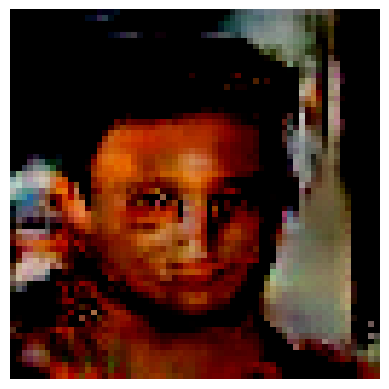

In [73]:
images = tf.random.normal(shape = (1, 100))

images = model.predict(images)

plt.axis('off')
plt.imshow(images[0])